### 3. Linear Regression
#### Step - 1 : Business Problem Understanding
- **Project Requirements : estimate the sales, based on total advertising spend**
- **Our next ad campaign will have a total spend, how many units do we expect to sell as a result of this ?**

- Collect & Load Data
- Dataset Understanding

#### Step - 2 : Data Understanding
##### Data
This sample data displays sales for a particular product as a function of advertising budgets (in dollars) for TV, radio, and newspaper media.

**Indepenent variables**
- TV: Advertising dollars spent on TV for a single product in a given market (in dollars)
- Radio: Advertising dollars spent on Radio
- Newspaper: Advertising dollars spent on Newspaper

**Target Variable**
- Sales: sales of a single product in a given market

In [2]:
import numpy as np 
import pandas as pd

In [3]:
df = pd.read_csv('Advertising.csv')
df = df.drop('Unnamed: 0', axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


**Data Understanding**

In [4]:
df.columns.tolist()

['TV', 'radio', 'newspaper', 'sales']

**Data nomeclature document**

This sample data displays sales for a particular product as a function of advertising budgets (in dollars) for TV, radio, and newspaper media.

- TV: Advertising dollars spent on TV for a single product in a given market (in dollars)
- Radio: Advertising dollars spent on Radio
- Newspaper: Advertising dollars spent on Newspaper
- Sales: sales of a single product (in units)

**Data Exploration** : Complete Observation on raw data

In [5]:
df.shape

(200, 4)

In [6]:
df.dtypes

TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

In [7]:
# For ex : in TV there is wrong data like "abc" or "xyz" instead of numeric values. 
# It will show as object data type instead of numeric. So we need to remove those rows.
l = []
for i in df.columns:
    if df[i].dtype == "object":
        l.append(i)
print(l)

[]


In [8]:
df["TV"].unique()

array([230.1,  44.5,  17.2, 151.5, 180.8,   8.7,  57.5, 120.2,   8.6,
       199.8,  66.1, 214.7,  23.8,  97.5, 204.1, 195.4,  67.8, 281.4,
        69.2, 147.3, 218.4, 237.4,  13.2, 228.3,  62.3, 262.9, 142.9,
       240.1, 248.8,  70.6, 292.9, 112.9,  97.2, 265.6,  95.7, 290.7,
       266.9,  74.7,  43.1, 228. , 202.5, 177. , 293.6, 206.9,  25.1,
       175.1,  89.7, 239.9, 227.2,  66.9, 100.4, 216.4, 182.6, 262.7,
       198.9,   7.3, 136.2, 210.8, 210.7,  53.5, 261.3, 239.3, 102.7,
       131.1,  69. ,  31.5, 139.3, 216.8, 199.1, 109.8,  26.8, 129.4,
       213.4,  16.9,  27.5, 120.5,   5.4, 116. ,  76.4, 239.8,  75.3,
        68.4, 213.5, 193.2,  76.3, 110.7,  88.3, 134.3,  28.6, 217.7,
       250.9, 107.4, 163.3, 197.6, 184.9, 289.7, 135.2, 222.4, 296.4,
       280.2, 187.9, 238.2, 137.9,  25. ,  90.4,  13.1, 255.4, 225.8,
       241.7, 175.7, 209.6,  78.2,  75.1, 139.2, 125.7,  19.4, 141.3,
        18.8, 224. , 123.1, 229.5,  87.2,   7.8,  80.2, 220.3,  59.6,
         0.7, 265.2,

In [9]:
df["radio"].unique()

array([37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6,  2.1,  2.6,  5.8,
       24. , 35.1,  7.6, 32.9, 47.7, 36.6, 39.6, 20.5, 23.9, 27.7,  5.1,
       15.9, 16.9, 12.6,  3.5, 29.3, 16.7, 27.1, 16. , 28.3, 17.4,  1.5,
       20. ,  1.4,  4.1, 43.8, 49.4, 26.7, 37.7, 22.3, 33.4,  8.4, 25.7,
       22.5,  9.9, 41.5, 15.8, 11.7,  3.1,  9.6, 41.7, 46.2, 28.8, 28.1,
       19.2, 49.6, 29.5,  2. , 42.7, 15.5, 29.6, 42.8,  9.3, 24.6, 14.5,
       27.5, 43.9, 30.6, 14.3, 33. ,  5.7, 43.7,  1.6, 28.5, 29.9,  7.7,
       20.3, 44.5, 43. , 18.4, 40.6, 25.5, 47.8,  4.9, 33.5, 36.5, 14. ,
       31.6, 21. , 42.3,  4.3, 36.3, 10.1, 17.2, 34.3, 46.4, 11. ,  0.3,
        0.4, 26.9,  8.2, 38. , 15.4, 20.6, 46.8, 35. ,  0.8, 36.9, 26.8,
       21.7,  2.4, 34.6, 32.3, 11.8, 38.9,  0. , 49. , 12. ,  2.9, 27.2,
       38.6, 47. , 39. , 28.9, 25.9, 17. , 35.4, 33.2, 14.8,  1.9,  7.3,
       40.3, 25.8, 13.9, 23.3, 39.7, 21.1, 11.6, 43.5,  1.3, 18.1, 35.8,
       36.8, 14.7,  3.4, 37.6,  5.2, 23.6, 10.6, 20

In [10]:
df["newspaper"].unique()

array([ 69.2,  45.1,  69.3,  58.5,  58.4,  75. ,  23.5,  11.6,   1. ,
        21.2,  24.2,   4. ,  65.9,   7.2,  46. ,  52.9, 114. ,  55.8,
        18.3,  19.1,  53.4,  49.6,  26.2,  19.5,  12.6,  22.9,  40.8,
        43.2,  38.6,  30. ,   0.3,   7.4,   8.5,   5. ,  45.7,  35.1,
        32. ,  31.6,  38.7,   1.8,  26.4,  43.3,  31.5,  35.7,  18.5,
        49.9,  36.8,  34.6,   3.6,  39.6,  58.7,  15.9,  60. ,  41.4,
        16.6,  37.7,   9.3,  21.4,  54.7,  27.3,   8.4,  28.9,   0.9,
         2.2,  10.2,  11. ,  27.2,  31.7,  19.3,  31.3,  13.1,  89.4,
        20.7,  14.2,   9.4,  23.1,  22.3,  36.9,  32.5,  35.6,  33.8,
        65.7,  16. ,  63.2,  73.4,  51.4,  33. ,  59. ,  72.3,  10.9,
         5.9,  22. ,  51.2,  45.9,  49.8, 100.9,  17.9,   5.3,  29.7,
        23.2,  25.6,   5.5,  56.5,   2.4,  10.7,  34.5,  52.7,  14.8,
        79.2,  46.2,  50.4,  15.6,  12.4,  74.2,  25.9,  50.6,   9.2,
         3.2,  43.1,   8.7,  43. ,   2.1,  65.6,  59.7,  20.5,   1.7,
        12.9,  75.6,

In [11]:
df["sales"].unique()

array([22.1, 10.4,  9.3, 18.5, 12.9,  7.2, 11.8, 13.2,  4.8, 10.6,  8.6,
       17.4,  9.2,  9.7, 19. , 22.4, 12.5, 24.4, 11.3, 14.6, 18. ,  5.6,
       15.5, 12. , 15. , 15.9, 18.9, 10.5, 21.4, 11.9,  9.6,  9.5, 12.8,
       25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7,  8.5, 14.9, 23.2, 14.8,
       11.4, 10.7, 22.6, 21.2, 20.2, 23.7,  5.5, 23.8, 18.4,  8.1, 24.2,
       15.7, 14. , 13.4, 22.3, 18.3, 12.4,  8.8, 11. , 17. ,  8.7,  6.9,
       14.2,  5.3, 12.3, 13.6, 21.7, 15.2, 16. , 16.7, 11.2,  7.3, 19.4,
       22.2, 11.5, 16.9, 11.7, 17.2, 19.2, 19.8, 21.8, 14.1, 12.6, 12.2,
        9.4,  6.6,  7. , 11.6, 19.7, 24.7,  1.6, 12.7,  5.7, 19.6, 10.8,
       20.8, 10.9, 20.1, 10.3, 16.1, 15.6,  3.2, 15.3, 14.4, 13.3,  8. ,
        8.4, 14.5,  7.6, 27. , 26.2, 17.6, 17.3,  6.7,  9.9,  5.9, 25.5])

In [12]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [13]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [14]:
# Observe any missing values in the dataset
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

#### Step - 3 : Data Preprocessing
- By combining all the features we get the "total spend** 

In [15]:
df["total_spend"] = df["TV"] + df["radio"] + df["newspaper"]
df.head()

,TV,radio,newspaper,sales,total_spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


In [16]:
df.drop(columns=["TV", "radio", "newspaper"], inplace=True)

In [17]:
df.head()

,sales,total_spend
0,22.1,337.1
1,10.4,128.9
2,9.3,132.4
3,18.5,251.3
4,12.9,250.0


In [18]:
df.corr() # Correlation between total_spend and sales is 0.897, 
# which is a strong positive correlation. 
# This indicates that as total spending on advertising increases, 
# sales also tend to increase.

,sales,total_spend
sales,1.000000,0.867712
total_spend,0.867712,1.000000


**Create X and y**

In [19]:
# SIMPLE LINEAR REGRESSION
X = df[["total_spend"]] # i/p features (can be multiple) should be in 2D array format, so we use double square brackets.
# This is due to the fact that scikit-learn expects the input features to be in a 2D array format, 
# even if there is only one feature.
y = df["sales"] # o/p feature can be in 1D array format, so we use single square brackets.

**Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# random state is used to lock the randomization process, so that we get the same results every time we run the code.

In [21]:
y_train

79     11.0
197    12.8
38     10.1
24      9.7
122    11.6
       ... 
106     7.2
14     19.0
92     19.4
179    12.6
102    14.8
Name: sales, Length: 160, dtype: float64

##### Algo-1 : Linear Regression
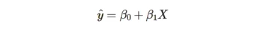

**Modelling**

In [22]:
# import
from sklearn.linear_model import LinearRegression

# save the model in a variable
model = LinearRegression()

# fit the model on the training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Prediction on train and test data**

In [23]:
# prediction on train data
y_train_pred = model.predict(X_train)

# Evaluate the model on train data
from sklearn.metrics import mean_squared_error, r2_score
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("Train MSE:", mse_train)
print("Train RMSE:", np.sqrt(mse_train))
print("Train R2 Score:", r2_train)

# prediction on test data
y_test_pred = model.predict(X_test)
# Evaluate the model on test data
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Test MSE:", mse_test)
print("Test RMSE:", np.sqrt(mse_test))
print("Test R2 Score:", r2_test)

Train MSE: 6.421575106597047
Train RMSE: 2.5340826952956856
Train R2 Score: 0.7524092686260717
Test MSE: 7.779806406885763
Test RMSE: 2.789230432733331
Test R2 Score: 0.7535196255373879


R^2 = 1 - (sigma(y - yhat)^2 / sigma(y - ybar)^2) = coefficient of determination
- yhat = mx + c (Regression) -> Today's best Model
- yhat = ybar (Average Model) -> befor MSE = sigma(y - ybar) / N

R^2 is
1. Comparison between average model and regression model 
2. How much percentage of error is dropped from comparison with average mode in regression model

`R^2 : (-inf , 1]`

R^2 can be negative will be possible when average model is better than the trained model

The model has an R2 score of around 0.75 on both train and test data, 
which indicates that the model explains about 75% of the variance in the 
target variable (sales) based on the input feature (total_spend).

The MSE and RMSE values are relatively low, suggesting that the model's predictions are reasonably close to the actual values. 

However, there is still some room for improvement, as the model does not capture all the variability in the data.

Train RMSE and Test RMSE are close to each other, which indicates that the model is not overfitting or underfitting the data.

If we get problem we will move to Non Linear One

##### Cross Validation Score
Cross Validation Score is a technique used to evaluate the performance of a machine learning model. 
It involves splitting the dataset into multiple subsets, training the model on some subsets and testing 
it on the remaining subset. This process is repeated multiple times, and the average score across all iterations 
is calculated to provide an estimate of the model's performance.
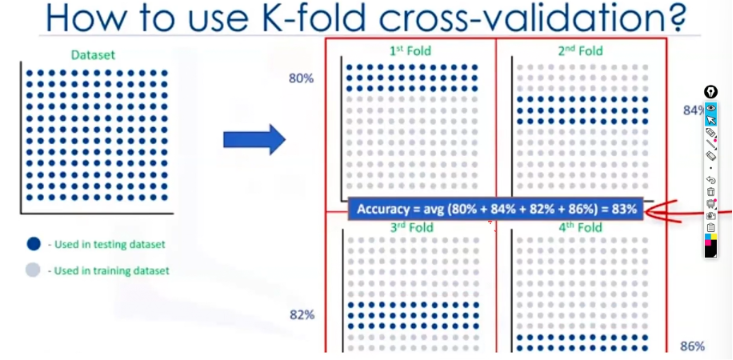


In [24]:
from sklearn.model_selection import cross_val_score

cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
# The `cross_val_score` function performs cross-validation on the given model, 
# input features (X), and target variable (y).
# The `cv=5` parameter specifies that we want to use 5-fold cross-validation, 
# which means the dataset will be split into 5 equal parts.
# The `scoring='r2'` parameter indicates that we want to evaluate the model 
# using the R-squared metric, which measures the proportion of variance in the 
# target variable that is explained by the model.
print("Cross-Validation R2 Scores:", cross_val_scores)
print("Average Cross-Validation R2 Score:", np.mean(cross_val_scores))

Cross-Validation R2 Scores: [0.71085815 0.71997547 0.75991704 0.71092584 0.71900225]
Average Cross-Validation R2 Score: 0.7241357509169324


##### Algo-2 - Lasso Linear Regression
Lasso regression is a linear regression technique that uses L1 regularization to prevent overfitting and improve model performance. It adds a penalty term to the loss function, which encourages the model to select only the most important features and shrink the coefficients of less important features to zero.

- as alpha increases, if there is no change in CV, then lasso not works for given dataset

- as alpha increases, if there is change in CV,
- then try different value by applying **GridSearchCV** , identify best alpha value

In [25]:
# To find the best alpha or another pararmeter for regularization, 
# Hyperparameter is a parameter that is set before the learning process begins 
# and is not updated during training.
# Hyperparameter tuning is the process of selecting the best hyperparameters for a 
# machine learning model to optimize its performance.

# Grid Search CV is a technique used to find the best hyperparameters for a machine learning model.
# It involves defining a grid of hyperparameter values and evaluating the model's performance for each combination.
# Grid Search CV uses cross-validation to assess the model's performance for each hyperparameter combination,
# and selects the combination that yields the best performance based on a specified evaluation metric.
# Grid -> within given values, Search -> search for best combination, CV -> cross validation

l = []
for i in range(1, 11):
    from sklearn.linear_model import Lasso
    lasso = Lasso(alpha=i)  # Setting the regularization parameter
    lasso.fit(X_train, y_train)
    cross_val_scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
    l.append((i, np.mean(cross_val_scores)))

print("Best Alpha:", max(l, key=lambda x: x[1])[0], "with Average R2 Score:", max(l, key=lambda x: x[1])[1])

# Grid Search CV uses for loop in background to find the best hyperparameter combination.

Best Alpha: 1 with Average R2 Score: 0.7241441169457137


In [26]:
from sklearn.model_selection import GridSearchCV

estimator = Lasso()
param_grid = {'alpha': list(range(1, 100))}  # List of alpha values to search over
# estimator is the model we want to tune,
# param_grid is a dictionary that defines the hyperparameter values to search over.

grid_search = GridSearchCV(estimator, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_score_

({'alpha': 1}, np.float64(0.7241441169457137))

In [27]:
# modelling
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
lasso_best = Lasso(alpha=0.1)  # Setting the regularization parameter
# alpha is the regularization parameter that controls the strength of the 
# penalty applied to the model's coefficients.
# Checking the effect of different alpha values on the model's performance can 
# help in selecting the optimal value for regularization.
lasso_best.fit(X_train, y_train)

# predictions
y_pred_lasso = lasso_best.predict(X_test)

# Cross-validation
cross_val_scores = cross_val_score(lasso_best, X_train, y_train, cv=5)

# test predictions
y_pred_lasso_test = lasso_best.predict(X_test)

# Evaluations
print("Training R2 Score:", lasso_best.score(X_train, y_train))
print("Testing R2 Score:", lasso_best.score(X_test, y_test))
print("Cross-Validation R2 Scores:", cross_val_scores)
print("Average Cross-Validation R2 Score:", np.mean(cross_val_scores))

Training R2 Score: 0.7524092212714037
Testing R2 Score: 0.7535287376249113
Cross-Validation R2 Scores: [0.71091489 0.71996482 0.75989197 0.71092479 0.71898917]
Average Cross-Validation R2 Score: 0.7241371258344269


For Lasso, Ridge, Elasticnet Regression
hyper parameters = models parameters
    - for lasso, ridge regression : alpha = 1 (default)
    - for elasticnet regression : alpha = 1 & lambda = 0.5 (default)
        50% lasso, 50% ridge

for lasso, ridge regression
we try different values of alpha --> where alpha is +ve integer starting : [0,inf)
if alpha= 0 (lasso regression = linear Regression)

How to try different values
 - first we try alpha values between 1 to 10, we check for each alpha value --> CV Score
 - if last value is having highest CV, try next values & continue the process
 - when you tried alpha in b/w 2 values, for each value if cv score is same --> lasso or ridge not works.



In [28]:
for i in range(1,10):
    for j in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:
        from sklearn. linear_model import ElasticNet
        en= ElasticNet(alpha=i, l1_ratio=j)
        en.fit(X_train,y_train)
        print("Alpha value:",i, "CV Score:",cross_val_score(en,X,y,cv=5).mean())

Alpha value: 1 CV Score: 0.7433802622872066
Alpha value: 1 CV Score: 0.7433833301717897
Alpha value: 1 CV Score: 0.743386317896667
Alpha value: 1 CV Score: 0.7433892254562355
Alpha value: 1 CV Score: 0.7433920528448918
Alpha value: 1 CV Score: 0.7433948000570322
Alpha value: 1 CV Score: 0.7433974670870521
Alpha value: 1 CV Score: 0.7434000539293475
Alpha value: 1 CV Score: 0.743402560578313
Alpha value: 1 CV Score: 0.7434049870283431
Alpha value: 1 CV Score: 0.7434073332738323


d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.139e+02, tolerance: 4.150e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.405e+02, tolerance: 4.383e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

Alpha value: 2 CV Score: 0.7433821851216665
Alpha value: 2 CV Score: 0.7433881577412654
Alpha value: 2 CV Score: 0.7433938097666279


d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.228e+02, tolerance: 4.199e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.903e+02, tolerance: 4.348e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

Alpha value: 2 CV Score: 0.7433991411529395
Alpha value: 2 CV Score: 0.74340415185538
Alpha value: 2 CV Score: 0.7434088418291228
Alpha value: 2 CV Score: 0.7434132110293348
Alpha value: 2 CV Score: 0.743417259411177
Alpha value: 2 CV Score: 0.7434209869298039
Alpha value: 2 CV Score: 0.7434243935403638
Alpha value: 2 CV Score: 0.7434274791979989
Alpha value: 3 CV Score: 0.7433840863738512
Alpha value: 3 CV Score: 0.7433928006797845
Alpha value: 3 CV Score: 0.7434007937489873
Alpha value: 3 CV Score: 0.743408065430246
Alpha value: 3 CV Score: 0.7434146155723154
Alpha value: 3 CV Score: 0.7434204440239188
Alpha value: 3 CV Score: 0.743425550633748
Alpha value: 3 CV Score: 0.7434299352504626
Alpha value: 3 CV Score: 0.7434335977226907
Alpha value: 3 CV Score: 0.7434365378990286
Alpha value: 3 CV Score: 0.743438755628041
Alpha value: 4 CV Score: 0.7433859660586803
Alpha value: 4 CV Score: 0.7433972591030896
Alpha value: 4 CV Score: 0.7434072701271492
Alpha value: 4 CV Score: 0.74341599877

d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.145e+02, tolerance: 4.150e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.411e+02, tolerance: 4.383e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

 4 CV Score: 0.7434344868513845
Alpha value: 4 CV Score: 0.7434380823964377
Alpha value: 4 CV Score: 0.7434403937695356
Alpha value: 4 CV Score: 0.7434414206117268
Alpha value: 4 CV Score: 0.7434411625639588
Alpha value: 5 CV Score: 0.7433878241910629
Alpha value: 5 CV Score: 0.7434015331268499
Alpha value: 5 CV Score: 0.7434132391843601
Alpha value: 5 CV Score: 0.7434229416638487
Alpha value: 5 CV Score: 0.7434306398653266
Alpha value: 5 CV Score: 0.7434363330885602
Alpha value: 5 CV Score: 0.743440020633071
Alpha value: 5 CV Score: 0.7434417017981361
Alpha value: 5 CV Score: 0.7434413758827872
Alpha value: 5 CV Score: 0.743439042185812
Alpha value: 5 CV Score: 0.7434347000057523


d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.149e+02, tolerance: 4.150e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.415e+02, tolerance: 4.383e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

Alpha value: 6 CV Score: 0.7433896607858971
Alpha value: 6 CV Score: 0.7434056228666629
Alpha value: 6 CV Score: 0.743418701203707
Alpha value: 6 CV Score: 0.7434288945881449
Alpha value: 6 CV Score: 0.7434362018105848
Alpha value: 6 CV Score: 0.7434406216611279
Alpha value: 6 CV Score: 0.7434421529293685
Alpha value: 6 CV Score: 0.7434407944043934
Alpha value: 6 CV Score: 0.7434365448747811
Alpha value: 6 CV Score: 0.743429403128603
Alpha value: 6 CV Score: 0.7434193679534218
Alpha value: 7 CV Score: 0.7433914758580719
Alpha value: 7 CV Score: 0.7434095284380531
Alpha value: 7 CV Score: 0.74342365646812
Alpha value: 7 CV Score: 0.7434338580290433
Alpha value: 7 CV Score: 0.7434401312006544
Alpha value: 7 CV Score: 0.7434424740618465
Alpha value: 7 CV Score: 0.7434408846905727
Alpha value: 7 CV Score: 0.7434353611638459
Alpha value: 7 CV Score: 0.7434259015577386
Alpha value: 7 CV Score: 0.7434125039473825
Alpha value: 7 CV Score: 0.7433951664069667
Alpha value: 8 CV Score: 0.743393269

d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.153e+02, tolerance: 4.150e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
d:\AI-Workspace\4.ML\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.419e+02, tolerance: 4.383e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeC

Alpha value: 8 CV Score: 0.7434362168667132
Alpha value: 8 CV Score: 0.7434254030249312
Alpha value: 8 CV Score: 0.743409446743768
Alpha value: 8 CV Score: 0.7433883451493977
Alpha value: 8 CV Score: 0.7433620953663878
Alpha value: 9 CV Score: 0.7433950414939435
Alpha value: 9 CV Score: 0.7434167875373003
Alpha value: 9 CV Score: 0.7434320478630723
Alpha value: 9 CV Score: 0.7434408183940444
Alpha value: 9 CV Score: 0.7434430950504386
Alpha value: 9 CV Score: 0.743438873749912
Alpha value: 9 CV Score: 0.7434281504075547
Alpha value: 9 CV Score: 0.7434109209358882
Alpha value: 9 CV Score: 0.743387181244864
Alpha value: 9 CV Score: 0.743356927241861
Alpha value: 9 CV Score: 0.7433201548316841


#### Non-Linear Regression

Non-LinearRegression is a type of regression analysis used to model the relationship between a dependent variable and one or more independent variables when the relationship is not linear. In non-linear regression, the model is represented by a non-linear equation, which can take various forms such as exponential, logarithmic, polynomial, or other complex functions.
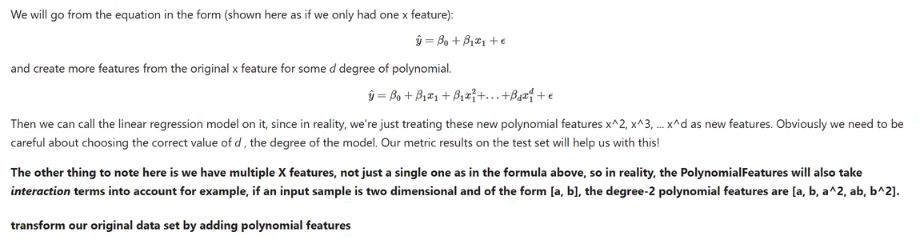

In [29]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_features = PolynomialFeatures(degree=3, include_bias=False)

# In above code, we are creating an instance of the PolynomialFeatures class with a degree of 2.

X_train_poly = pd.DataFrame(polynomial_features.fit_transform(X_train))
X_train_poly
# Here, we are transforming the original input features (X_train) into polynomial features of degree 2.


,0,1,2
0,146.8,21550.24,3.163575e+06
1,192.7,37133.29,7.155585e+06
2,104.9,11004.01,1.154321e+06
3,93.2,8686.24,8.095576e+05
4,242.0,58564.00,1.417249e+07
...,...,...,...
155,65.7,4316.49,2.835934e+05
156,283.0,80089.00,2.266519e+07
157,310.2,96224.04,2.984870e+07
158,193.2,37326.24,7.211430e+06


In [39]:
%%timeit

from sklearn.linear_model import LinearRegression
nlr_model = LinearRegression()
nlr_model.fit(X_train_poly, y_train)

941 μs ± 11.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [41]:
nlr_model = LinearRegression()
nlr_model.fit(X_train_poly, y_train)
print("Intercept :", nlr_model.intercept_)
print("Coefficients :", nlr_model.coef_)

# prediction on train data
ypred_train_poly = nlr_model.predict(X_train_poly)

# Also transform X_test for later predictions
X_test_poly = pd.DataFrame(polynomial_features.transform(X_test))

# train R2
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("Train R2 Score:", r2_score(y_train, ypred_train_poly))
print("Train MSE:", mean_squared_error(y_train, ypred_train_poly))
print("Train MAE:", mean_absolute_error(y_train, ypred_train_poly))

# Cross-validation Score
from sklearn.model_selection import cross_val_score
cross_val_scores_poly = cross_val_score(nlr_model, X_train_poly, y_train, cv=5, scoring='r2')
print("Cross-Validation R2 Scores:", cross_val_scores_poly)
print("Mean Cross-Validation R2 Score:", cross_val_scores_poly.mean())

Intercept : 2.0350088801025006
Coefficients : [ 9.46360272e-02 -2.56087139e-04  4.11871593e-07]
Train R2 Score: 0.7603254862829246
Train MSE: 6.216258106394497
Train MAE: 1.9048764108859
Cross-Validation R2 Scores: [0.7153215  0.63425976 0.77461818 0.72254482 0.72514113]
Mean Cross-Validation R2 Score: 0.7143770771975286


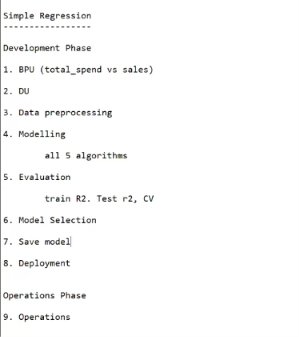

##### Model Selection
1. 1st Priority : High Test R2
2. 2nd Priority : If 2 model have same test R2, then observe CV
3. 3rd Priority : If 2 models have same test R2, same CV, then time

Conclusion : Non Linear Regression (d = 3) is final model for our project with 75.42 %

##### Save the Model

In [ ]:
from joblib import dump
dump(nlr_model, 'linear_regression_model.joblib')

['linear_regression_model.joblib']

##### Using model by deployment team

In [59]:
import pandas as pd

df = pd.DataFrame({'total_spend': [100, 200, 300, 400, 500]})
df

,total_spend
0,100
1,200
2,300
3,400
4,500


In [60]:
# Future Data
df = pd.DataFrame({"tv": [100, 200, 300], "radio": [50, 60, 70], "newspaper": [20, 30, 40]})
df

,tv,radio,newspaper
0,100,50,20
1,200,60,30
2,300,70,40


In [61]:
# data preprocessing
df["total_spend"] = df["tv"] + df["radio"] + df["newspaper"]

In [62]:
df = df.drop(columns=["tv", "radio", "newspaper"])
df

,total_spend
0,170
1,290
2,410


In [63]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree=3, include_bias=False)
X = pd.DataFrame(polynomial_converter.fit_transform(df))

# In above code, we are creating an instance of the PolynomialFeatures class with a degree of 3.

In [64]:
X

,0,1,2
0,170.0,28900.0,4913000.0
1,290.0,84100.0,24389000.0
2,410.0,168100.0,68921000.0


In [67]:
# Predicting future sales using the trained model 
from joblib import load
given_model = load('linear_regression_model.joblib')

predicted_sales = given_model.predict(df)
print("Minimum Expected Sales : " , round(predicted_sales.min()))
print("Maximum Expected Sales : " , round(predicted_sales.max()))


Minimum Expected Sales :  12
Maximum Expected Sales :  24
